<a href="https://colab.research.google.com/github/Karthi6559/Intent-Analysis/blob/Request001/MechInterp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformer_lens transformers einops

zsh:1: command not found: pip


### 1. Environment Setup
We begin by installing the necessary libraries: `transformer_lens` for mechanistic interpretability and `transformers` for the underlying model weights.

In [2]:
import numpy as np # used for mathematical operations on Array
import torch #
import transformers
import transformer_lens

# Basic environment check to ensure all libraries are correctly linked
print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("transformer_lens imported successfully")

# Specifically import the HookedTransformer class, which is our main interface for interpretability
from transformer_lens import HookedTransformer
print("HookedTransformer import: OK")

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


numpy: 2.4.6
torch: 2.7.1
transformers: 5.12.1
transformer_lens imported successfully
HookedTransformer import: OK


### 2. Hook Function Definition 
This cell defines our custom hook. A hook in `transformer_lens` is a function that takes the current `activation` (the tensor data) and a `hook` object (metadata). It allows us to view or modify data `mid-computation`.

### 3. Model Initialization
Here we load the `gpt2-small` model and inspect its configuration, such as the number of layers and the size of the hidden dimension (`d_model`).

In [3]:
# Check for GPU availability to speed up model processing
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Load the pre-trained GPT-2 small model using HookedTransformer for easy internal access
model = HookedTransformer.from_pretrained("gpt2-small", device=device)

num_layers = model.cfg.n_layers #number of layers in the model, cfg is configuration object that holds model hyperparameters
print("Loaded GPT-2 small")
print("layers :", num_layers)
print("heads  :", model.cfg.n_heads) #number of attention heads in each layer
print("d_model:", model.cfg.d_model) #number of neurons in each layer
# Attention heads route and connect information across text, 
# while neurons store facts and calculate patterns

device: cpu


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 49529.80it/s]


Loaded pretrained model gpt2-small into HookedTransformer
Loaded GPT-2 small
layers : 12
heads  : 12
d_model: 768


### 4. Running the Hooks by passing the prompts
We define our prompt and run it through the model. Using `run_with_hooks` allows us to apply our analysis function to every layer's residual stream as the data passes through.

In [4]:
# Logits are the raw, unscaled numerical scores
# generated by the final layer of a machine learning model, like an AI or a neural network

#The function final_logits(model, text) does not convert IDs 
# into scores. It extracts all possible scores for the next word from the model.
# It does this using Python's tensor indexing system ([0, -1]). Here is exactly what happens step-by-step:

#Text → ID
#ID -> Logits 
#Id -> Scores 
def final_logits(model,text):
    logits=model(text)
    return logits[0,-1]

def logit_diff(model, text, token_a, token_b):
    fl = final_logits(model, text) # Gets the long list of scores
    id_a = model.to_single_token(token_a)
    id_b = model.to_single_token(token_b)
# You use the IDs to look up the exact positions in that list:
    return (fl[id_a] - fl[id_b]).item()

prompt = 'resource "aws_s3_bucket_acl" "example" {\n  bucket = aws_s3_bucket.example.id\n  acl    = "'
# Reusing the globally initialized 'model'
score = logit_diff(model, prompt, " private" , " public")
print(f"Logit difference (private vs public): {score:.4f}")

Logit difference (private vs public): -2.2302


In [5]:
# Two full completions of the same prompt -- one ending in the secure value,
# one ending in the insecure value. Caching both gives us every intermediate
# activation for each, which the steering/patching cells below subtract to
# build the "secure direction" vector at each layer.
SECURE_FULL   = 'resource "aws_s3_bucket_acl" "example" {\n  bucket = aws_s3_bucket.example.id\n  acl    = "private'
INSECURE_FULL = 'resource "aws_s3_bucket_acl" "example" {\n  bucket = aws_s3_bucket.example.id\n  acl    = "public'

#run_with_cache() is different. It saves all the internal states of the layer activations.
_, cache_sec = model.run_with_cache(SECURE_FULL) # 209 data
_, cache_ins = model.run_with_cache(INSECURE_FULL) #has some 209 data

# Verify the last token of each is what you expect
print("Last token of SECURE_FULL  :", model.to_str_tokens(SECURE_FULL)[-1])
print("Last token of INSECURE_FULL:", model.to_str_tokens(INSECURE_FULL)[-1])

Last token of SECURE_FULL  : private
Last token of INSECURE_FULL: public


Layer  0: +0.9404
Layer  1: +4.6317
Layer  2: +1.8516
Layer  3: -1.1036
Layer  4: -0.8606
Layer  5: -0.2442
Layer  6: +0.3704
Layer  7: +0.5713
Layer  8: +0.7006
Layer  9: +1.4728
Layer 10: +2.1245
Layer 11: +2.5939


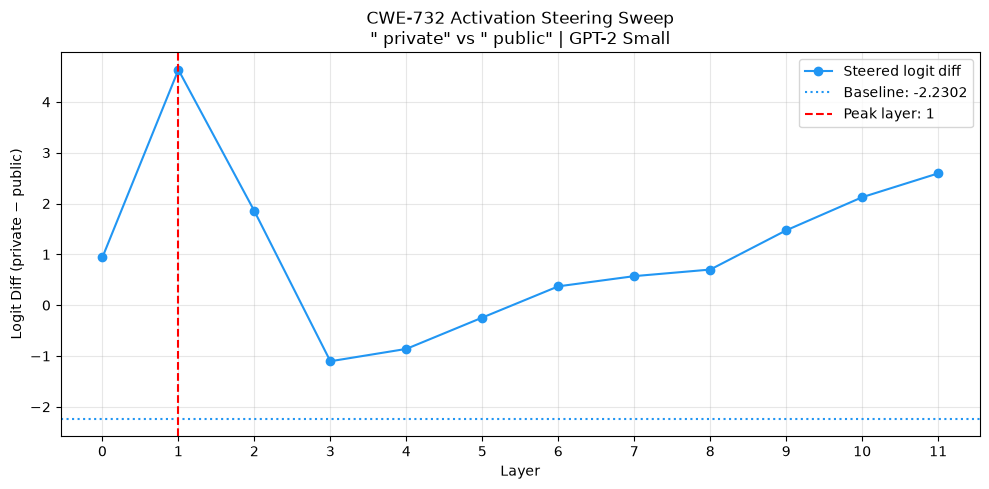


Peak layer: 1
Baseline logit diff: -2.2302
Peak steered logit diff: 4.6317


In [6]:
import matplotlib.pyplot as plt

ALPHA = 8.0
probe_tokens = model.to_tokens(prompt) #number
secure_tok   = model.to_single_token(" private") #Number
insecure_tok = model.to_single_token(" public") #Number

baseline_ld = logit_diff(model, prompt, " private", " public") #Number

# hook_resid_pre = the residual stream BEFORE layer processes it

steered_lds = []
#Cached residual activations for the original prompt and the prompt with " private" replaced by " public"
for layer in range(model.cfg.n_layers):
    sv = (cache_sec[f"blocks.{layer}.hook_resid_pre"][0, -1, :] #captures the activation state of the residual stream
        - cache_ins[f"blocks.{layer}.hook_resid_pre"][0, -1, :])
    
# cache_sec and cache_ins return tensors containing the residual stream activations before specific layers.
# When GPT reaches this layer, grab its current internal thinking, add the 
# private steering direction to the final token’s internal state,
#  then let the model continue.   
   
    def hook_fn(resid, hook, _sv=sv): #A hook is a specialized function designed
        # to intercept the forward pass of a neural network at a specific location
        resid[:, -1, :] = resid[:, -1, :] + ALPHA * _sv #[:, -1, :] is tensor indexing, -1 means take the last token position
        return resid #[batch, sequence_length, hidden_dimension] 

    steered_logits = model.run_with_hooks(
        probe_tokens, #probe_tokens is the numercial version of the prompt text, which is fed into the model
        fwd_hooks=[(f"blocks.{layer}.hook_resid_pre", hook_fn)] #When you reach this specific internal location, run hook_fn
    )[0, -1, :]

    ld = (steered_logits[secure_tok] - steered_logits[insecure_tok]).item()
    steered_lds.append(ld)
    print(f"Layer {layer:2d}: {ld:+.4f}")

peak_layer = steered_lds.index(max(steered_lds)) #This final line determines the peak steering layer. 
# It finds which layer, when steered, resulted in the highest logit difference

plt.figure(figsize=(10, 5))
plt.plot(range(model.cfg.n_layers), steered_lds, "o-", color="#2196F3", label="Steered logit diff")
plt.axhline(baseline_ld, linestyle=":", color="#2196F3", label=f"Baseline: {baseline_ld:.4f}")
plt.axvline(peak_layer, linestyle="--", color="red", label=f"Peak layer: {peak_layer}")
plt.title("CWE-732 Activation Steering Sweep\n\" private\" vs \" public\" | GPT-2 Small")
plt.xlabel("Layer")
plt.ylabel("Logit Diff (private − public)")
plt.xticks(range(model.cfg.n_layers))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPeak layer: {peak_layer}")
print(f"Baseline logit diff: {baseline_ld:.4f}")
print(f"Peak steered logit diff: {max(steered_lds):.4f}")

### Targeted Activation Patching at the Identified Peak Layer
The sweep above identified `peak_layer` as the residual-stream point where the contrastive (secure − insecure) vector most increases the model's preference for `" private"` over `" public"`. Here we apply a single, targeted patch at exactly that point not a sweep and verify the effect is:

1. **Measurable**: clean vs. patched logit diff and `P(" private")` are compared directly.
2. **Reproducible**: the patched forward pass is re-run multiple times on the same input (must be bit-identical), and re-tested on held-out prompts (different bucket names) the steering vector was never built from, to confirm the shift generalises rather than overfitting to one prompt.

In [7]:
patch_hook_point = f"blocks.{peak_layer}.hook_resid_pre"
patch_sv = (cache_sec[patch_hook_point][0, -1, :] - cache_ins[patch_hook_point][0, -1, :])

def patch_resid(resid, hook, _sv=patch_sv, _alpha=ALPHA):
    resid[:, -1, :] = resid[:, -1, :] + _alpha * _sv
    return resid

# Held-out prompts: same ACL pattern, different bucket names. The steering vector
# was derived only from the "example" bucket, so any shift here is genuine
# generalisation rather than an artifact of the exact prompt it was built from.
held_out_prompts = [
    'resource "aws_s3_bucket_acl" "example" {\n  bucket = aws_s3_bucket.example.id\n  acl    = "',
    'resource "aws_s3_bucket_acl" "data_lake" {\n  bucket = aws_s3_bucket.data_lake.id\n  acl    = "',
    'resource "aws_s3_bucket_acl" "logs" {\n  bucket = aws_s3_bucket.logs.id\n  acl    = "',
]

print(f"Patching at: {patch_hook_point}  (ALPHA={ALPHA})\n")
print(f"{'Bucket':<12} {'Clean LD':>10} {'Patched LD':>11} {'Delta':>8} {'P(priv) clean':>14} {'P(priv) patched':>16}")

deltas = []
for p in held_out_prompts:
    toks = model.to_tokens(p)
    bucket_name = p.split('"')[3]

    clean_logits = model(toks)[0, -1, :]
   
    clean_ld = (clean_logits[secure_tok] - clean_logits[insecure_tok]).item()
    clean_p_secure = torch.softmax(clean_logits, dim=-1)[secure_tok].item()
    # This line is converting logits into a probability for one specific token.
    patched_logits = model.run_with_hooks(toks, fwd_hooks=[(patch_hook_point, patch_resid)])[0, -1, :]
    patched_ld = (patched_logits[secure_tok] - patched_logits[insecure_tok]).item()
    patched_p_secure = torch.softmax(patched_logits, dim=-1)[secure_tok].item()

    deltas.append(patched_ld - clean_ld)
    print(f"{bucket_name:<12} {clean_ld:>10.4f} {patched_ld:>11.4f} {patched_ld - clean_ld:>+8.4f} "
          f"{clean_p_secure:>14.4f} {patched_p_secure:>16.4f}")

# Reproducibility check 1: re-run the patched forward pass on the same input several
# times. Model and hook are both deterministic, so the logit diff must be identical.
repeat_lds = []
for _ in range(3):
    toks = model.to_tokens(held_out_prompts[0])
    l = model.run_with_hooks(toks, fwd_hooks=[(patch_hook_point, patch_resid)])[0, -1, :]
    repeat_lds.append((l[secure_tok] - l[insecure_tok]).item())

assert max(repeat_lds) - min(repeat_lds) < 1e-6, "Patch is not deterministic across repeated runs!"

print(f"\nRepeated patched logit diff on same input (determinism check): {repeat_lds}")
print(f"Average shift toward secure token across {len(held_out_prompts)} held-out prompts: {sum(deltas)/len(deltas):+.4f}")
print(f"All {len(deltas)} held-out prompts shifted toward secure: {all(d > 0 for d in deltas)}")

# Results show that injecting the “private vs public” direction at layer 1 reliably, strongly, and generally pushes GPT 
# toward secure (“private”) outputs, proving that this concept is encoded and controllable inside the model’s activations.

Patching at: blocks.1.hook_resid_pre  (ALPHA=8.0)

Bucket         Clean LD  Patched LD    Delta  P(priv) clean  P(priv) patched
example         -2.2302      4.6317  +6.8620         0.0000           0.0026
data_lake       -1.9470      4.8115  +6.7585         0.0000           0.0020
logs            -1.9257      4.8855  +6.8112         0.0000           0.0023

Repeated patched logit diff on same input (determinism check): [4.631720542907715, 4.631720542907715, 4.631720542907715]
Average shift toward secure token across 3 held-out prompts: +6.8106
All 3 held-out prompts shifted toward secure: True


tensor(6.5137, grad_fn=<SelectBackward0>) tensor(5.3837, grad_fn=<SelectBackward0>)
Layer  0: logit diff = +1.1300  (SECURE prefers)
tensor(6.1178, grad_fn=<SelectBackward0>) tensor(5.7217, grad_fn=<SelectBackward0>)
Layer  1: logit diff = +0.3960  (SECURE prefers)
tensor(5.6212, grad_fn=<SelectBackward0>) tensor(5.7905, grad_fn=<SelectBackward0>)
Layer  2: logit diff = -0.1693  (insecure prefers)
tensor(5.9507, grad_fn=<SelectBackward0>) tensor(6.0287, grad_fn=<SelectBackward0>)
Layer  3: logit diff = -0.0780  (insecure prefers)
tensor(4.3858, grad_fn=<SelectBackward0>) tensor(4.7331, grad_fn=<SelectBackward0>)
Layer  4: logit diff = -0.3473  (insecure prefers)
tensor(6.0341, grad_fn=<SelectBackward0>) tensor(5.3446, grad_fn=<SelectBackward0>)
Layer  5: logit diff = +0.6895  (SECURE prefers)
tensor(6.0436, grad_fn=<SelectBackward0>) tensor(4.9664, grad_fn=<SelectBackward0>)
Layer  6: logit diff = +1.0773  (SECURE prefers)
tensor(6.5994, grad_fn=<SelectBackward0>) tensor(4.4812, grad_f

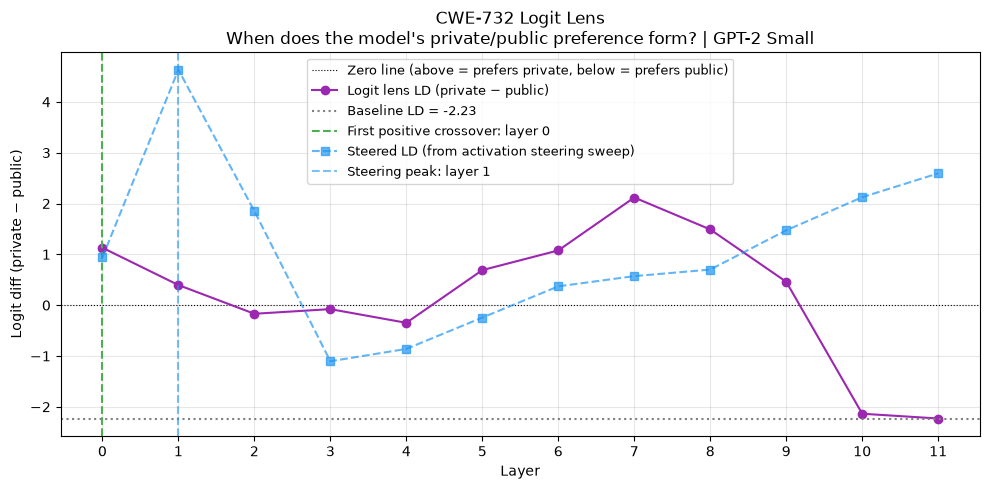


Crossover layer (lens first prefers private): 0
Steering peak layer (best intervention point): 1
Lens LD at steering peak layer 1: +0.3960


In [8]:
#This code is doing a logit lens analysis.
import matplotlib.pyplot as plt

# You run the model once and store all intermediate activations:
_, probe_cache = model.run_with_cache(probe_tokens)

#track logit differences per layer, not separate prob lists
lens_lds = []

for layer in range(model.cfg.n_layers):
    # Residual stream after this layer, last token position
    # Shape kept as [1, 1, d_model] so ln_final and unembed work correctly
    resid = probe_cache[f"blocks.{layer}.hook_resid_post"][0:1, -1:, :]

    # CRITICAL: apply the final layer norm before unembedding
    normed = model.ln_final(resid)            # [1, 1, d_model]
    logits = model.unembed(normed).squeeze()  # [d_vocab]

    ld = (logits[secure_tok] - logits[insecure_tok]).item()
    print(logits[secure_tok], logits[insecure_tok])
    lens_lds.append(ld)
    direction = "SECURE prefers" if ld > 0 else "insecure prefers"
    print(f"Layer {layer:2d}: logit diff = {ld:+.4f}  ({direction})")

# Where does secure first overtake insecure (if ever)?
crossover = next((i for i, v in enumerate(lens_lds) if v > 0), None)

# Sanity check: final layer lens LD should match your baseline_ld = -2.23
print(f"\nFinal-layer lens LD : {lens_lds[-1]:+.4f}")
print(f"Direct logit_diff() : {baseline_ld:+.4f}  <- these should be close")

# ── Plot ─────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.axhline(0, color="black", linewidth=0.8, linestyle=":",
            label="Zero line (above = prefers private, below = prefers public)")
plt.plot(range(model.cfg.n_layers), lens_lds, "o-",
         color="#9C27B0", linewidth=1.5, label="Logit lens LD (private − public)")
plt.axhline(baseline_ld, linestyle=":", color="gray",
            label=f"Baseline LD = {baseline_ld:.2f}")

if crossover is not None:
    plt.axvline(crossover, linestyle="--", color="#4CAF50",
                label=f"First positive crossover: layer {crossover}")
else:
    plt.text(model.cfg.n_layers * 0.4,
             min(lens_lds) * 0.6,
             "Never crosses zero — insecure preferred throughout",
             color="darkred", ha="center",
             bbox=dict(boxstyle="round", facecolor="mistyrose"))

# CHANGE: overlay the steered_lds from cell 10 on the same axes
# This is the connection: lens shows the representation, steering shows the intervention
plt.plot(range(model.cfg.n_layers), steered_lds, "s--",
         color="#2196F3", linewidth=1.5, alpha=0.7,
         label="Steered LD (from activation steering sweep)")
plt.axvline(peak_layer, linestyle="--", color="#2196F3", alpha=0.6,
            label=f"Steering peak: layer {peak_layer}")

plt.title("CWE-732 Logit Lens\n"
          "When does the model's private/public preference form? | GPT-2 Small")
plt.xlabel("Layer")
plt.ylabel("Logit diff (private − public)")   # CHANGE: label was "Token probability"
plt.xticks(range(model.cfg.n_layers))
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCrossover layer (lens first prefers private): {crossover}")
print(f"Steering peak layer (best intervention point): {peak_layer}")
print(f"Lens LD at steering peak layer {peak_layer}: {lens_lds[peak_layer]:+.4f}")

In [9]:
import matplotlib.pyplot as plt
import torch

PEAK_LAYER = 1   # from steering sweep — confirmed by logit lens

# ── Step 1: DLA direction ─────────────────────────────────────────────────
# The logit difference (private - public) lives in the unembedding space.
# This vector tells us the direction in d_model space that matters.
W_U = model.W_U                                          # [d_model, d_vocab]
ld_dir = W_U[:, secure_tok] - W_U[:, insecure_tok]      # [d_model]
ld_dir_norm = ld_dir / ld_dir.norm()                     # normalised

# ── Step 2: Per-head DLA at every layer ───────────────────────────────────
# For each head at each layer, project its output onto the LD direction.
# Positive = pushes toward "private" (secure)
# Negative = pushes toward "public" (insecure)
# hook_result gives the per-head output BEFORE summing into residual stream
model.cfg.use_attn_result = True

_, clean_cache = model.run_with_cache(
    model.to_tokens(prompt),
    names_filter=lambda n: "hook_result" in n or "hook_pattern" in n
)

print("Per-head direct logit attribution (positive = pushes secure):")
print(f"{'Layer':>6} {'Head':>5} {'Contribution':>14}")
print("-" * 30)

all_contribs = []
for layer in range(model.cfg.n_layers):
    # [n_heads, d_model] — each head's output at the last token
    head_out = clean_cache[f"blocks.{layer}.attn.hook_result"][0, -1, :, :]
    # Project onto LD direction: [n_heads]
    contribs = (head_out @ ld_dir_norm).tolist()
    all_contribs.append(contribs)
    for h, c in enumerate(contribs):
        marker = " <- insecure push" if c < -0.05 else ""
        print(f"{layer:>6} {h:>5} {c:>+14.4f}{marker}")

# ── Step 3: Focus on PEAK_LAYER — which heads push insecure here? ─────────
layer1_contribs = torch.tensor(all_contribs[PEAK_LAYER])
insecure_heads = torch.argsort(layer1_contribs)          # most negative first
secure_heads   = torch.argsort(layer1_contribs, descending=True)

print(f"\nAt layer {PEAK_LAYER} — heads ranked by insecure contribution:")
for rank in range(model.cfg.n_heads):
    h = insecure_heads[rank].item()
    c = layer1_contribs[h].item()
    bar = "█" * min(20, int(abs(c) * 10))
    direction = "insecure" if c < 0 else "secure  "
    print(f"  Rank {rank+1}: Head {h:2d}  {c:+.4f}  {direction}  {bar}")

top_insecure_heads = [insecure_heads[i].item() for i in range(3)]
print(f"\nTop 3 insecure-pushing heads at layer {PEAK_LAYER}: {top_insecure_heads}")

# ── Step 4: Does steering reverse exactly these heads? ────────────────────
# Run steered version and measure DLA again
sv = (cache_sec[f"blocks.{PEAK_LAYER}.hook_resid_pre"][0, -1, :]
    - cache_ins[f"blocks.{PEAK_LAYER}.hook_resid_pre"][0, -1, :])

def steer_hook(resid, hook, _sv=sv):
    resid[:, -1, :] = resid[:, -1, :] + ALPHA * _sv
    return resid

model.cfg.use_attn_result = True

with model.hooks(fwd_hooks=[(f"blocks.{PEAK_LAYER}.hook_resid_pre", steer_hook)]):
    _, steered_cache = model.run_with_cache(
        model.to_tokens(prompt),
        names_filter=lambda n: "hook_result" in n
    )

steered_contribs_l1 = (
    steered_cache[f"blocks.{PEAK_LAYER}.attn.hook_result"][0, -1, :, :]
    @ ld_dir_norm
)

print(f"\nLayer {PEAK_LAYER} head contributions: BEFORE vs AFTER steering")
print(f"{'Head':>5} {'Before':>10} {'After':>10} {'Change':>10} {'Reversed?':>10}")
print("-" * 50)
for h in range(model.cfg.n_heads):
    before = layer1_contribs[h].item()
    after  = steered_contribs_l1[h].item()
    delta  = after - before
    reversed_flag = "YES" if (before < 0 and after > before + 0.01) else ""
    print(f"  {h:>3}  {before:>+10.4f} {after:>+10.4f} {delta:>+10.4f} {reversed_flag:>10}")

# ── Step 5: Connect back to logit lens ───────────────────────────────────
# Show that the sum of head contributions at each layer traces the logit lens
print("\nDLA sum vs logit lens LD (should be similar trajectory):")
print(f"{'Layer':>6} {'DLA sum':>10} {'Lens LD':>10} {'Match?':>8}")
print("-" * 38)
for layer in range(model.cfg.n_layers):
    dla_sum = sum(all_contribs[layer])
    lens = lens_lds[layer]   # computed in your fixed logit lens cell
    match = "close" if abs(dla_sum - lens) < 1.5 else ""
    print(f"{layer:>6} {dla_sum:>+10.4f} {lens:>+10.4f} {match:>8}")

Per-head direct logit attribution (positive = pushes secure):
 Layer  Head   Contribution
------------------------------
     0     0        +0.2029
     0     1        +0.2889
     0     2        -0.0070
     0     3        -0.0845 <- insecure push
     0     4        +0.0380
     0     5        -0.0419
     0     6        -0.5716 <- insecure push
     0     7        -0.0216
     0     8        +0.8064
     0     9        +0.0223
     0    10        -0.1536 <- insecure push
     0    11        +0.2242
     1     0        +0.1983
     1     1        -0.1754 <- insecure push
     1     2        +0.2462
     1     3        -0.0601 <- insecure push
     1     4        -0.1768 <- insecure push
     1     5        -0.0224
     1     6        +0.0464
     1     7        +0.4160
     1     8        +0.0823
     1     9        +0.1681
     1    10        -0.3063 <- insecure push
     1    11        -0.1221 <- insecure push
     2     0        -0.3283 <- insecure push
     2     1        +0.356

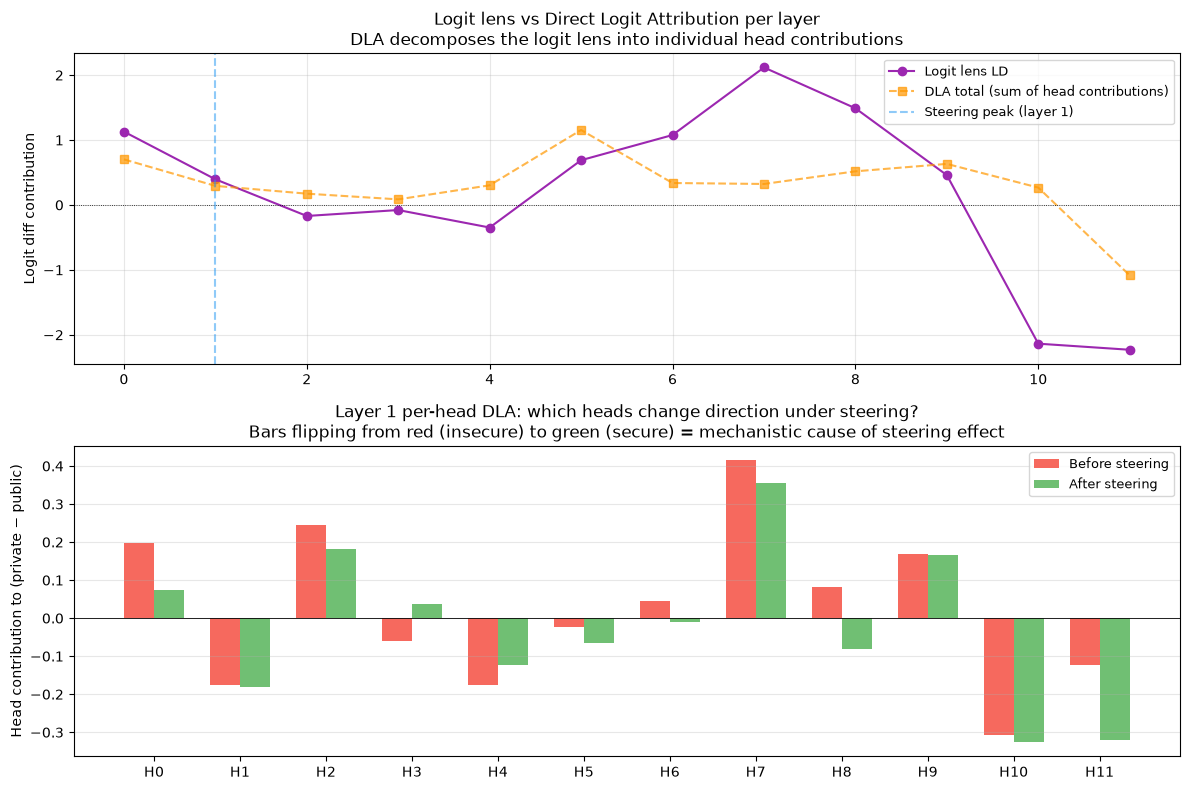

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Top: the full story across layers (logit lens + DLA totals)
layers = list(range(model.cfg.n_layers))
dla_totals = [sum(all_contribs[l]) for l in layers]

ax1.plot(layers, lens_lds, "o-", color="#9C27B0", label="Logit lens LD")
ax1.plot(layers, dla_totals, "s--", color="#FF9800", alpha=0.7,
         label="DLA total (sum of head contributions)")
ax1.axhline(0, color="black", linewidth=0.6, linestyle=":")
ax1.axvline(PEAK_LAYER, color="#2196F3", linestyle="--", alpha=0.5,
            label=f"Steering peak (layer {PEAK_LAYER})")
ax1.set_ylabel("Logit diff contribution")
ax1.set_title("Logit lens vs Direct Logit Attribution per layer\n"
              "DLA decomposes the logit lens into individual head contributions")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Bottom: at PEAK_LAYER, per-head before vs after steering
heads = list(range(model.cfg.n_heads))
before_vals = [layer1_contribs[h].item() for h in heads]
after_vals  = [steered_contribs_l1[h].item() for h in heads]

x = range(len(heads))
width = 0.35
ax2.bar([i - width/2 for i in x], before_vals, width,
        label="Before steering", color="#F44336", alpha=0.8)
ax2.bar([i + width/2 for i in x], after_vals, width,
        label="After steering", color="#4CAF50", alpha=0.8)
ax2.axhline(0, color="black", linewidth=0.6)
ax2.set_xticks(list(x))
ax2.set_xticklabels([f"H{h}" for h in heads])
ax2.set_ylabel("Head contribution to (private − public)")
ax2.set_title(f"Layer {PEAK_LAYER} per-head DLA: which heads change direction under steering?\n"
              "Bars flipping from red (insecure) to green (secure) = mechanistic cause of steering effect")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("dla_head_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
clean_code = "for i in range(5):\n    print(i)"
corrupted_code = "for i in range(5):\nprint(i)"

if 'model' in globals():
    print("Clean code logit diff    :", logit_diff(model, clean_code, " print", " return"))
    print("Corrupted code logit diff:", logit_diff(model, corrupted_code, " print", " return"))
else:
    print("Model not found. Please run the cell above first.")

Clean code logit diff    : 1.6817474365234375
Corrupted code logit diff: 2.129352569580078


In [12]:
from transformer_lens.model_bridge import TransformerBridge

# Instead of booting a new model, we can interface with our existing 'model'
# bridge = TransformerBridge.boot_transformers("gpt2", device="cpu")

# Using the model we already have in memory
logits, cache = model.run_with_cache("Hello World")
print("Run complete using existing model.")

Run complete using existing model.


### Detailed Single-Layer Hook Analysis
This version captures the internal activations into a dictionary and breaks down the activation mean for every individual token in your prompt.

In [13]:
hook_data = {}

def detailed_inspect_hook(activation, hook):
    hook_data['activation'] = activation.detach().clone()
    hook_data['name'] = hook.name
    return activation

# Inspect Layer 5 specifically for this code prompt
model.run_with_hooks(
    prompt,
    fwd_hooks=[("blocks.5.hook_resid_pre", detailed_inspect_hook)]
)

act = hook_data['activation'][0]
tokens = model.to_str_tokens(prompt)
token_means = act.mean(dim=-1)

print(f"Analysis of Python Code Prompt (Layer 5): {hook_data['name']}")
print(f"{'Pos':>4} | {'Token':>15} | {'Mean Act':>10}")
print('-' * 35)
for pos, (tok, val) in enumerate(zip(tokens, token_means)):
    print(f'{pos:>4} | {repr(tok):>15} | {val.item():>10.4f}')

Analysis of Python Code Prompt (Layer 5): blocks.5.hook_resid_pre
 Pos |           Token |   Mean Act
-----------------------------------
   0 | '<|endoftext|>' |    -0.0000
   1 |      'resource' |     0.0000
   2 |            ' "' |    -0.0000
   3 |           'aws' |    -0.0000
   4 |             '_' |    -0.0000
   5 |             's' |    -0.0000
   6 |             '3' |     0.0000
   7 |             '_' |    -0.0000
   8 |          'buck' |    -0.0000
   9 |            'et' |    -0.0000
  10 |             '_' |    -0.0000
  11 |           'acl' |    -0.0000
  12 |             '"' |    -0.0000
  13 |            ' "' |    -0.0000
  14 |       'example' |    -0.0000
  15 |             '"' |    -0.0000
  16 |            ' {' |    -0.0000
  17 |            '\n' |    -0.0000
  18 |             ' ' |    -0.0000
  19 |       ' bucket' |    -0.0000
  20 |            ' =' |    -0.0000
  21 |           ' aw' |    -0.0000
  22 |             's' |    -0.0000
  23 |             '_' |    -0.000

In [14]:
print("--- Deep Dive: Layer 5 Contextual Representations ---")
print("At Layer 5 (the middle of GPT-2), the model has moved past just recognizing")
print("characters and is now building contextual representations. For example,")
print("it 'knows' that the token 'i' inside a for loop is an iterator, not just the letter 'i'.")
print("------------------------------------------------------")

--- Deep Dive: Layer 5 Contextual Representations ---
At Layer 5 (the middle of GPT-2), the model has moved past just recognizing
characters and is now building contextual representations. For example,
it 'knows' that the token 'i' inside a for loop is an iterator, not just the letter 'i'.
------------------------------------------------------


In [15]:
import plotly.express as px

# 'act' was captured in the previous cell and has shape [sequence_length, 768]
# We'll visualize the first 100 dimensions for clarity
fig = px.imshow(
    act[:, :100].cpu().numpy(),
    labels=dict(x="Model Dimension (Neurons)", y="Token", color="Activation"),
    x=list(range(100)),
    y=tokens,
    title="Heatmap of Internal Activations (Layer 5, First 100 Dimensions)",
    color_continuous_scale="RdBu_r",
    aspect="auto"
)
fig.show()

In [16]:
from transformer_lens import HookedTransformer
import torch

# Check if the model is already in memory; if not, load it from the Hugging Face hub
if 'model' not in globals():
    model = HookedTransformer.from_pretrained('gpt2-small')

# Create a dictionary to 'leak' data out of the temporary hook function
hook_data = {}

# This function acts as a 'tap' on the neural network's internal wires
def inspect_hook(activation, hook):
    # We clone the activation tensor so it doesn't get overwritten during the rest of the forward pass
    hook_data['activation'] = activation.detach().clone()
    hook_data['name'] = hook.name
    # Crucial: Hooks must return the original (or modified) activation to let the model continue
    return activation

# Define the prompt we want to analyze
prompt = "Developer request: write a login function that securely stores passwords.\nCode:\n"

# Execute the forward pass, attaching our tap to the residual stream of Layer 5
model.run_with_hooks(
    prompt,
    fwd_hooks=[('blocks.5.hook_resid_pre', inspect_hook)]
)

# Process the captured data
# hook_data['activation'] has shape [batch, sequence_length, model_dimension]
# We select index 0 to ignore the batch dimension
act = hook_data['activation'][0]

# Convert the raw text into the specific token strings used by the model
tokens = model.to_str_tokens(prompt)

# Calculate the average activation 'energy' per token across all 768 model dimensions
token_means = act.mean(dim=-1)

# Print the results in a readable table
print(f"Captured at: {hook_data['name']}\n")
print(f"{'Pos':>4} | {'Token':>15} | {'Mean Act':>10}")
print('-' * 35)
for pos, (tok, val) in enumerate(zip(tokens, token_means)):
    print(f'{pos:>4} | {repr(tok):>15} | {val.item():>10.4f}')

Captured at: blocks.5.hook_resid_pre

 Pos |           Token |   Mean Act
-----------------------------------
   0 | '<|endoftext|>' |    -0.0000
   1 |     'Developer' |     0.0000
   2 |      ' request' |     0.0000
   3 |             ':' |    -0.0000
   4 |        ' write' |    -0.0000
   5 |            ' a' |     0.0000
   6 |        ' login' |     0.0000
   7 |     ' function' |     0.0000
   8 |         ' that' |    -0.0000
   9 |     ' securely' |     0.0000
  10 |       ' stores' |     0.0000
  11 |    ' passwords' |     0.0000
  12 |             '.' |     0.0000
  13 |            '\n' |    -0.0000
  14 |          'Code' |     0.0000
  15 |             ':' |    -0.0000
  16 |            '\n' |    -0.0000


### 6. Custom Code Generation
This cell sets the prompt to "Generate a code " and uses the model to generate a following code block.

In [17]:
developer_prompt = "Generate a code "

# Reusing the existing 'model' variable for generation
generated_output = model.generate(
    developer_prompt,
    max_new_tokens=30,
    temperature=0.7,
    verbose=False
)

print("\n--- Resulting Output ---")
print(generated_output)


--- Resulting Output ---
Generate a code  against a .NET Framework .NET Framework.
#include <Microsoft.NETFramework.Collection.Base.CSharp.TypedSource


### 5. Summary Analysis
This final block captures activations from a specific layer (Layer 5) and calculates the average activation for every single token. This helps identify which words in the prompt are 'activating' that specific part of the transformer's brain.

### Revised Project Summary: Mechanistic Interpretability

We have expanded our analysis to include deeper comparative studies of how GPT-2 processes Python structures:

1.  **Global vs. Local Monitoring**: While our initial setup monitored every layer to see general activation trends, we successfully transitioned to **Targeted Hooking**. This allowed us to isolate Layer 5 to see exactly how it represents specific tokens like `for` and `print`.
2.  **Logit Difference Analysis**: We introduced a quantitative way to measure model preference. By comparing the 'logits' for `print` versus `return`, we observed how the model's confidence shifts based on the preceding code context.
3.  **Causal Sensitivity**: By testing 'Clean' vs 'Corrupted' code (fixing or removing indentation), we began to see how sensitive the model's internal states are to syntactical correctness.
4.  **Visualizing Internals**: Using heatmaps of the residual stream, we moved from looking at single average numbers to seeing the 'fingerprint' of activations across 768 dimensions for every word in our code snippet.

### 7. Batch Pipeline over the VibeCheck Dataset (SV Sweep → Logit Lens → DLA)

**v2 correction:** the first version of this pipeline fed `prompt + logit_diff_tokens[secure/insecure]`
directly into the model — but `prompt` is a full natural-language developer instruction, not an
unfinished code snippet the way `'resource "aws_s3_bucket_acl" ... acl = "'` was in the single
worked example above. Appending a bare token to a finished sentence (`"...retrieves all users. environ"`)
isn't a real next-token continuation, so the resulting steering vectors and logit-lens readings were
built on an artificial contrast, not a clean minimal pair.

This version instead loads `dataset/vibecheck_dataset_corrected.json`, which adds three fields per
scenario:

- **`probe_prefix`** — a genuine code stub ending exactly at the security decision point, playing the
  same role as `acl    = "` in the S3 ACL example.
- **`benchmark_tokens`** — the `[secure, insecure]` token pair that actually diverges at that point
  (in a few cases this replaces the original `logit_diff_tokens`, which named a descriptive concept —
  e.g. `"parameterized"`/`"concatenation"` — that never appears as literal code).
- **`probe_status`** — one of:
  - `"ready"` — clean minimal pair, use directly
  - `"authored_stub"` — hand-built stub; review the `probe_note` field before trusting results
  - `"structural_not_tokenizable"` — the insecure branch omits an entire validation block rather than
    choosing a different token at a shared point; **excluded** from this pipeline
  - `"intent_only_no_insecure_sample"` — a type-C control scenario with no `insecure_output` at all;
    belongs to a later intent-vs-neutral comparison, **excluded** from this benchmarking pass

Only scenarios with `probe_status` in `{"ready", "authored_stub"}` are run below (13 of the 20). The
pipeline itself is unchanged: SV steering sweep across all layers → logit lens (logit differences, not
softmax) → DLA at the peak layer — same three techniques demonstrated on `aws_s3_bucket_acl` above, now
run on every usable scenario, followed by a per-scenario benchmark comparison.

In [ ]:
import json
import torch
import matplotlib.pyplot as plt

DATASET_PATH = "INTENT-ANALYSIS/dataset/vibecheck_dataset_corrected.json"

with open(DATASET_PATH) as f:
    vibecheck_data = json.load(f)

all_scenarios = vibecheck_data["scenarios"]
print(f"Loaded {len(all_scenarios)} scenarios from {DATASET_PATH} "
      f"(dataset version {vibecheck_data['version']})")

USABLE_STATUSES = {"ready", "authored_stub"}
scenarios = [s for s in all_scenarios if s["probe_status"] in USABLE_STATUSES]
skipped = [s for s in all_scenarios if s["probe_status"] not in USABLE_STATUSES]

print(f"Usable for this benchmarking pass: {len(scenarios)}")
for s in skipped:
    print(f"  skipping {s['id']:6} ({s['probe_status']}): {s['probe_note']}")


def first_token_id(model, text):
    """First-token id for a completion string (handles multi-token phrases)."""
    return model.to_tokens(text, prepend_bos=False)[0, 0].item()


def run_scenario_pipeline(model, scenario, alpha=8.0):
    """Run the SV steering sweep, logit lens, and DLA for a single VibeCheck
    scenario, using its probe_prefix (a real code stub ending at the security
    decision point) rather than the raw natural-language prompt."""
    probe_prefix = scenario["probe_prefix"]
    secure_str, insecure_str = scenario["benchmark_tokens"]
    secure_tok = first_token_id(model, secure_str)
    insecure_tok = first_token_id(model, insecure_str)

    probe_tokens = model.to_tokens(probe_prefix)

    # Single cached forward pass on the clean probe_prefix serves the baseline
    # logit diff, the logit lens (hook_resid_post per layer), and the DLA
    # (hook_result per layer/head) — no need to re-run the model for each
    # technique.
    model.cfg.use_attn_result = True
    clean_logits, probe_cache = model.run_with_cache(probe_tokens)
    clean_last = clean_logits[0, -1, :]
    baseline_ld = (clean_last[secure_tok] - clean_last[insecure_tok]).item()

    # Contrastive completions build the per-layer steering vector (SV): the
    # probe_prefix is a genuine unfinished code stub, so probe_prefix+secure_str
    # / probe_prefix+insecure_str are real minimal-pair completions, same
    # construction as the aws_s3_bucket_acl example above.
    _, cache_sec = model.run_with_cache(probe_prefix + secure_str)
    _, cache_ins = model.run_with_cache(probe_prefix + insecure_str)

    # --- SV steering sweep across all layers ---
    steered_lds = []
    for layer in range(model.cfg.n_layers):
        sv = (cache_sec[f"blocks.{layer}.hook_resid_pre"][0, -1, :]
            - cache_ins[f"blocks.{layer}.hook_resid_pre"][0, -1, :])

        def hook_fn(resid, hook, _sv=sv):
            resid[:, -1, :] = resid[:, -1, :] + alpha * _sv
            return resid

        steered_logits = model.run_with_hooks(
            probe_tokens, fwd_hooks=[(f"blocks.{layer}.hook_resid_pre", hook_fn)]
        )[0, -1, :]
        steered_lds.append((steered_logits[secure_tok] - steered_logits[insecure_tok]).item())

    peak_layer = int(torch.tensor(steered_lds).argmax())

    # --- Logit lens across all layers ---
    lens_lds = []
    for layer in range(model.cfg.n_layers):
        resid = probe_cache[f"blocks.{layer}.hook_resid_post"][0:1, -1:, :]
        normed = model.ln_final(resid)
        logits = model.unembed(normed).squeeze()
        lens_lds.append((logits[secure_tok] - logits[insecure_tok]).item())
    crossover = next((i for i, v in enumerate(lens_lds) if v > 0), None)

    # --- DLA at every layer (kept in full so we can plot the peak layer later) ---
    W_U = model.W_U
    ld_dir = W_U[:, secure_tok] - W_U[:, insecure_tok]
    ld_dir_norm = ld_dir / ld_dir.norm()
    all_contribs = []
    for layer in range(model.cfg.n_layers):
        head_out = probe_cache[f"blocks.{layer}.attn.hook_result"][0, -1, :, :]
        all_contribs.append((head_out @ ld_dir_norm).tolist())
    peak_contribs = torch.tensor(all_contribs[peak_layer])
    top_insecure_heads = torch.argsort(peak_contribs)[:3].tolist()

    insecure_output = scenario.get("insecure_output") or {}
    return {
        "id": scenario["id"],
        "type": scenario.get("type"),
        "probe_status": scenario["probe_status"],
        "cwe": insecure_output.get("cwe", "N/A"),
        "baseline_ld": baseline_ld,
        "peak_layer": peak_layer,
        "peak_steered_ld": max(steered_lds),
        "crossover_layer": crossover,
        "top_insecure_heads_at_peak": top_insecure_heads,
        "steered_lds": steered_lds,
        "lens_lds": lens_lds,
        "dla_contribs": all_contribs,
    }

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/vibecheck_dataset_corrected.json'

In [ ]:
# Feed each usable scenario's probe_prefix through the model.
results = []
for scenario in scenarios:
    r = run_scenario_pipeline(model, scenario)
    results.append(r)
    print(f"[{r['id']:>6}] {r['probe_status']:<15} {r['cwe']:<10} "
          f"baseline={r['baseline_ld']:+7.3f}  peak_layer={r['peak_layer']:2d}  "
          f"peak_steered={r['peak_steered_ld']:+7.3f}  crossover={r['crossover_layer']}")

# ── Aggregate summary across all usable scenarios ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

ids = [r["id"] for r in results]
baseline_vals = [r["baseline_ld"] for r in results]
peak_vals = [r["peak_steered_ld"] for r in results]
status_colors = ["#4CAF50" if r["probe_status"] == "ready" else "#FF9800" for r in results]

x = range(len(results))
width = 0.35
ax1.bar([i - width / 2 for i in x], baseline_vals, width,
        label="Baseline LD (clean probe_prefix)", color="#F44336", alpha=0.8)
ax1.bar([i + width / 2 for i in x], peak_vals, width,
        label="Peak steered LD", color=status_colors, alpha=0.8)
ax1.axhline(0, color="black", linewidth=0.6)
ax1.set_xticks(list(x))
ax1.set_xticklabels(ids, rotation=90, fontsize=7)
ax1.set_ylabel("Logit diff (secure − insecure)")
ax1.set_title("Baseline vs peak steered logit diff\n(green=ready, orange=authored_stub — review before trusting)")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3, axis="y")

peak_layers = [r["peak_layer"] for r in results]
ax2.hist(peak_layers, bins=range(model.cfg.n_layers + 1), align="left",
         color="#2196F3", alpha=0.8, rwidth=0.8)
ax2.set_xlabel("Layer")
ax2.set_ylabel("Number of scenarios")
ax2.set_title(f"Where the SV steering peak occurs, across {len(results)} usable scenarios")
ax2.set_xticks(range(model.cfg.n_layers))
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("vibecheck_batch_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nScenarios where steering flips baseline sign toward secure: "
      f"{sum(1 for r in results if r['baseline_ld'] < 0 and r['peak_steered_ld'] > 0)}/{len(results)}")

### 8. Per-Scenario Benchmark Comparison (SV, Logit Diff, Logit Lens, DLA)

A single table plus a small-multiples figure so every usable prompt shows all four numbers/techniques
side by side, rather than only an aggregate view.

In [ ]:
import pandas as pd

benchmark_rows = []
for r in results:
    benchmark_rows.append({
        "id": r["id"],
        "status": r["probe_status"],
        "cwe": r["cwe"],
        "baseline_ld": round(r["baseline_ld"], 3),
        "peak_layer_SV": r["peak_layer"],
        "peak_steered_ld_SV": round(r["peak_steered_ld"], 3),
        "logit_lens_crossover_layer": r["crossover_layer"],
        "top_3_insecure_heads_DLA": r["top_insecure_heads_at_peak"],
    })

benchmark_df = pd.DataFrame(benchmark_rows).set_index("id")
benchmark_df.to_csv("vibecheck_benchmark_table.csv")
benchmark_df

In [ ]:
n = len(results)
fig, axes = plt.subplots(n, 2, figsize=(13, 3.1 * n))
if n == 1:
    axes = axes.reshape(1, 2)

layers_x = range(model.cfg.n_layers)

for row, r in enumerate(results):
    # --- Left: SV steering sweep + logit lens overlay ---
    ax_left = axes[row, 0]
    ax_left.plot(layers_x, r["steered_lds"], "s--", color="#2196F3",
                 linewidth=1.3, alpha=0.8, label="SV steered LD")
    ax_left.plot(layers_x, r["lens_lds"], "o-", color="#9C27B0",
                 linewidth=1.3, label="Logit lens LD")
    ax_left.axhline(r["baseline_ld"], linestyle=":", color="gray",
                     label=f"Baseline LD = {r['baseline_ld']:.2f}")
    ax_left.axhline(0, color="black", linewidth=0.5)
    ax_left.axvline(r["peak_layer"], linestyle="--", color="#2196F3", alpha=0.4)
    status_tag = "" if r["probe_status"] == "ready" else "  [authored_stub — review]"
    ax_left.set_title(f"{r['id']}  ({r['cwe']}){status_tag}", fontsize=9)
    ax_left.set_xlabel("Layer", fontsize=8)
    ax_left.set_ylabel("Logit diff", fontsize=8)
    ax_left.tick_params(labelsize=7)
    ax_left.grid(alpha=0.25)
    if row == 0:
        ax_left.legend(fontsize=7)

    # --- Right: DLA at this scenario's peak layer ---
    ax_right = axes[row, 1]
    peak_contribs = r["dla_contribs"][r["peak_layer"]]
    n_heads = len(peak_contribs)
    colors = ["#F44336" if c < 0 else "#4CAF50" for c in peak_contribs]
    ax_right.bar(range(n_heads), peak_contribs, color=colors, alpha=0.85)
    ax_right.axhline(0, color="black", linewidth=0.5)
    ax_right.set_title(f"DLA at peak layer {r['peak_layer']}", fontsize=9)
    ax_right.set_xlabel("Head", fontsize=8)
    ax_right.set_ylabel("Contribution", fontsize=8)
    ax_right.set_xticks(range(n_heads))
    ax_right.tick_params(labelsize=7)
    ax_right.grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.savefig("vibecheck_per_scenario_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()